In [73]:
from langchain_upstage import UpstageEmbeddings
from langchain_chroma import Chroma
from langchain_anthropic import ChatAnthropic
from langsmith import Client
from dotenv import load_dotenv

load_dotenv()

embedding = UpstageEmbeddings(model="solar-embedding-1-large")

# database = Chroma.from_documents(
#     documents=splits,
#     embedding=embedding,
#     collection_name='chroma-tax',
#     persist_directory='./preprocessed-upstage'
# )
database = Chroma(
  collection_name= 'chroma-tax',
  persist_directory= './preprocessed-upstage',
  embedding_function= embedding     
)

retriever = database.as_retriever(
    search_type= 'mmr',
    search_kwargs={
        'k': 4,
        'fetch_k': 10,
        'lambda_mult': 0.6
    }
)

client = Client()

# 비용의 80%는 Haiku가, 정확도의 80%는 Sonnet/Opus가!!

smart_llm = ChatAnthropic(
    model='claude-opus-4-5-20251101',
    temperature= 0
)

llm = ChatAnthropic(
    model='claude-sonnet-4-5-20250929',
    temperature= 0
)

small_llm = ChatAnthropic(
    model='claude-haiku-4-5-20251001',
    temperature= 0
)

In [74]:
from langchain_community.tools.tavily_search import TavilySearchResults

search_tool = TavilySearchResults()

In [75]:
from langchain_core.tools.retriever import create_retriever_tool
from langchain_core.prompts import PromptTemplate

retriever_tool = create_retriever_tool(
    retriever=retriever,
    name='search_tax_law',  # 동사로 시작하는 이름 권장
    description='''소득세 관련 법령 조문을 검색합니다.

이럴 때 사용:
- 과세표준 계산 근거가 필요할 때
- 세율표, 공제 조건 등 법적 기준 확인
- 특정 조문 번호로 검색 (예: "종부세법 9조")

이럴 때 사용하지 마세요:
- 단순 세금 계산 → calculate_tax 도구
- 최신 공시가격/공정시장가액비율 → web_search 도구

반환: 관련 법령 조문 (최대 4개, 출처 포함)
''',
    document_prompt=PromptTemplate.from_template(
        "[{source} {article}]\n{page_content}"
    ),
    document_separator="\n\n"
)

In [76]:
from langchain_core.tools import tool
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_community.utilities.semanticscholar import SemanticScholarAPIWrapper


@tool       # 데코레이터 @tool로 감싸고
def add(num1: int, num2: int) -> int:     # 함수와 변수의 이름, typehint가 schema(구조)로서, JSON 형식으로 LLM에 전달됨
    '''
    정수 num1와 num2를 더합니다. 
    '''         # 이 부분의 description(프롬프트와 같음)도 마찬가지로 LLM에 전달됨
    return num1+num2

@tool
def multiply(num1: int, num2: int) -> int:
    '''
    정수 num1와 num2를 곱합니다. 
    '''
    return num1*num2

@tool
def search(query: str) -> str:
    '''
    사용자의 질문에 알고 있는 지식만으로 답변하기 힘든 경우,
    주어진 query에 대해 DuckDuckGo 검색을 수행하고, 요약된 결과를 반환합니다.
    '''
    # 1. 검색 수행
    results = search_tool.invoke(query)
    
    # 2. 요약 프롬프트
    prompt = ChatPromptTemplate.from_messages([
        ("system", "당신은 검색 결과를 요약하는 전문가입니다. 검색 결과를 바탕으로 사용자의 질문에 간결하고 정확하게 답변하세요."),
        ("human", "질문: {query}\n\n검색 결과:\n{results}\n\n위 검색 결과를 바탕으로 질문에 답변해주세요.")
    ])
    
    # 3. Chain 구성 (비용 절약을 위해 small_llm 사용)
    chain = prompt | small_llm | StrOutputParser()
    
    # 4. 요약 실행
    summary = chain.invoke({"query": query, "results": results})
    
    return summary


semantic_scholar_wrapper = SemanticScholarAPIWrapper(
    top_k_results=5,
    doc_content_chars_max=6000,  # 더 긴 초록
)

@tool
def search_semantic_scholar(query: str) -> str:
    '''
    Semantic Scholar에서 peer-reviewed 학술 논문을 검색합니다.
    인용 수(citation count)가 포함되어 논문 품질을 판단할 수 있습니다.
    
    Args:
        query: 검색어 (예: "LLM agent reasoning")
    '''
    return semantic_scholar_wrapper.run(query)




In [ ]:
@tool
def search_income_tax_law(query: str) -> str:
    '''소득세 관련 법령 조문을 검색합니다.

    이럴 때 사용:
    - 과세표준 계산 근거가 필요할 때
    - 세율표, 공제 조건 등 법적 기준 확인
    - 특정 조문 번호로 검색 (예: "소득세법 55조")

    이럴 때 사용하지 마세요:
    - 단순 세금 계산 → calculate_tax 도구
    - 최신 세율/공제 한도 → web_search 도구

    반환: 관련 법령 조문 (최대 4개, 출처 포함)
    '''
    try:
        docs = retriever.invoke(query)
    except Exception as e:
        return f"검색 중 오류 발생: {str(e)}"
    
    if not docs:
        return "관련 법령을 찾지 못했습니다. 다른 키워드로 검색해주세요."
    
    # 중복 조문 제거
    seen = set()
    unique_docs = []
    for doc in docs:
        key = doc.metadata.get('article', doc.page_content[:50])
        if key not in seen:
            seen.add(key)
            unique_docs.append(doc)
    
    # 포맷팅
    results = []
    for doc in unique_docs[:4]:
        source = doc.metadata.get('source', '출처 미상')
        article = doc.metadata.get('article', '')
        results.append(f"[{source} {article}]\n{doc.page_content}")
    
    return "\n\n".join(results)

In [ ]:
from langgraph.prebuilt import ToolNode

tool_list = [add, multiply, search, search_semantic_scholar, search_income_tax_law]

llm_with_tools = small_llm.bind_tools(tool_list)

tool_node = ToolNode(tool_list)

In [79]:
from langgraph.graph import START, END
from langgraph.graph import MessagesState, StateGraph

def agent(state: MessagesState):
    messages = state['messages']
    response = llm_with_tools.invoke(messages)
    return {'messages': [response]}

def should_continue(state: MessagesState):
    messages = state['messages']
    if messages[-1].tool_calls:
        return 'tools'
    return END

graph_builder = StateGraph(MessagesState)


graph_builder.add_node('agent', agent) 
graph_builder.add_node('tools', tool_node)

graph_builder.add_edge(START, 'agent')
graph_builder.add_conditional_edges(
    'agent', 
    should_continue,
    {
        'tools': 'tools',
        END: END
    }
)
graph_builder.add_edge('tools', 'agent')

graph = graph_builder.compile()

In [82]:
from langchain_core.messages import HumanMessage


for chunk in graph.stream({'messages': [HumanMessage("소득세 과세표준 계산 방법")]}, stream_mode= 'values'):
    chunk['messages'][-1].pretty_print()

================================ Human Message =================================

소득세 과세표준 계산 방법
================================== Ai Message ==================================

[{'text': '소득세 과세표준 계산 방법에 대해 법령 정보를 검색해드리겠습니다.', 'type': 'text'}, {'id': 'toolu_019v6cU6DKNefeQnrmzGubbC', 'input': {'query': '과세표준 계산 방법'}, 'name': 'search_income_tax_law', 'type': 'tool_use'}]
Tool Calls:
  search_income_tax_law (toolu_019v6cU6DKNefeQnrmzGubbC)
 Call ID: toolu_019v6cU6DKNefeQnrmzGubbC
  Args:
    query: 과세표준 계산 방법
================================= Tool Message =================================
Name: search_income_tax_law

[Tax_with_table.docx ]
2. 이 법 또는 이 법 외의 법률에 따라 양도소득세의 감면에 관한 규정을 적용받았거나 받을 경우: 감면에 관한 규정을 적용받았거나 받을 경우의 해당 감면세액과 매매계약서의 거래가액과 실지거래가액과의 차액 중 적은 금액

[전문개정 2010. 12. 27.]



제3절 양도소득과세표준과 세액의 계산 <개정 2009. 12. 31.>



제92조(양도소득과세표준과 세액의 계산) ① 거주자의 양도소득에 대한 과세표준(이하 “양도소득과세표준”이라 한다)은 종합소득 및 퇴직소득에 대한 과세표준과 구분하여 계산한다. <개정 2020. 12. 29., 2024. 12. 31.>

② 양도소득과세표준은 다음 각 호의 순서에 따라 계

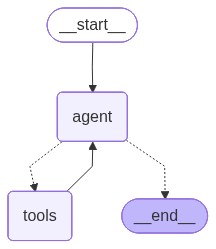

In [40]:
from IPython.display import display, Image

display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
'''
하고싶은것들

1. Dart API OpenDartReader
금융감독원 전자공시 시스템의 "Open DART" 서비스 API 사용해서
재무제표 데이터(손익계산서, 재무상태표, 현금흐름표), 
기업 정보 조회(사업보고서, 분기보고서, 반기보고서), 
주식 관련 정보(주식 총수, 주주 구성, 주식 변동 사항)

등을 제공받아 기업 분석 도구 만들기

2. 여러 Tool들 개발하고 Deep Agent 통해서 나만의 Agent 만들기

3. Node 분할 등의 기법들 
pip install langgraph langchain-openai
pip install langgraph-supervisor langgraph-swarm
pip install deepagents

4. multi-agent 아키텍쳐 패턴
    1. Router Pattern: 분할 정복 라우팅
    2. Supervisor Pattern: 중앙 집중식 조율
    3. Swarm Pattern: 분산 협업
    4. Plan-and-Execute: 계획 분리 전략
    5. 동적 도구 관리: Dynamic Tool Selection (도구 목록을 Retrieve해 동적 할당)

    
    6. Deep Agents: 차세대 에이전트 아키텍처
'''

In [ ]:
'''
claude code 동작 원리 중 인상적인 것들
https://claude.ai/public/artifacts/a5bc33eb-1e43-4aab-8a5f-b45094f00871

#1
중요한 점은 Anthropic이 임베딩 기반 RAG를 선택하지 않았다는 것이다.
대신 bash 명령어(head, tail, grep)를 통한 직접 탐색을 사용한다.

#2
gather context → take action → verify work → repeat

#3
4단계: 루프 종료 조건
루프는 Claude가 도구 호출 없이 일반 텍스트 응답을 반환할 때 자연스럽게 종료된다. 
이것이 Claude가 작업이 완료되었다고 판단한다는 신호다. 
성공 판단 기준은 모든 테스트 통과, 빌드 성공, 린터 통과, TodoList의 모든 항목 "completed" 상태
Headless/CI 모드에서는 maxTurns 파라미터로 최대 반복 횟수를 제한할 수 있으며,
컨텍스트 윈도우 한계에 도달하면 자동 압축(compaction)이 발생한다.

#4
Context Engineering: 컨텍스트는 유한한 자원이다
Anthropic의 2025년 9월 엔지니어링 블로그에서 강조하는 핵심 개념이 Context Engineering이다.
컨텍스트 윈도우의 토큰 수가 증가할수록 모델의 정보 회상 정확도가 떨어지는 
Context Rot 현상이 발생하기 때문이다.

#5
컨텍스트 관리 3원칙
첫째, 최소한의 고신호 토큰 집합을 찾아야 한다.
    원하는 결과의 가능성을 최대화하는 최소한의 정보만 포함해야 한다.
둘째, Just-in-Time 검색을 활용한다. 
    모든 데이터를 미리 로드하지 않고 필요할 때 검색한다.
셋째, **점진적 공개(Progressive Disclosure)**를 통해 
    에이전트가 탐색을 통해 컨텍스트를 점진적으로 발견하도록 한다.

#6
자동 압축(Compaction) 시스템
Claude Code는 컨텍스트 사용량이 **약 92%**에 도달하면 자동으로 압축을 실행한다.
이전 메시지를 요약하고, 파일 수정 사항과 TodoList 상태는 보존하며,
최근 접근한 5개 파일은 유지한다. 
사용자가 /clear 명령을 자주 사용하여 작업 간 컨텍스트를 리셋하는 것도 권장된다. 
'''

In [ ]:
'''
(벡터 RAG) 조문별 청킹하고 메타데이터를 tool에 반영해서 retrieve tool을 만들어보기

(Graph RAG) Neo4j를 활용해 국가법령정보센터 XML 참조를 그래프에 반영하고
그래프 탐색 기반 retrieve tool 만들어보기

(Hybrid RAG) 벡터+그래프 RAG 기반 retrieve tool 만들어보기
'''